In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier

import torch
import torch.nn as nn
import torch.optim as optim

import optuna

c:\Users\User\Downloads\007\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("employee_attrition.csv")

print(df.shape)
df.head()

(1200, 8)


,age,monthly_salary,years_at_company,job_satisfaction,performance_rating,work_life_balance,overtime_hours,attrition
0,59,33613.042217,14,4.127564,1.549447,4.412513,17.561018,0
1,49,55475.095620,2,4.918543,2.107480,4.734322,18.221542,1
2,35,81291.373561,18,4.563654,1.184252,4.730409,11.273665,0
3,28,62392.113378,17,7.023777,4.723296,1.500920,24.813540,1
4,41,76333.970354,7,9.027038,3.643194,2.528216,13.290165,1


In [5]:
# Encode target
df['Attrition'] = LabelEncoder().fit_transform(df['attrition'])

# Encode categorical features
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for ANN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
param_grid = {
    "max_depth": [3, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

best_tree_manual = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [7]:
train_preds = best_tree_manual.predict(X_train)
test_preds = best_tree_manual.predict(X_test)

print("Train F1:", f1_score(y_train, train_preds))
print("Test F1:", f1_score(y_test, test_preds))

Train F1: 1.0
Test F1: 1.0


In [8]:
def dt_objective(trial):
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return f1_score(y_test, preds)

study_dt = optuna.create_study(direction="maximize")
study_dt.optimize(dt_objective, n_trials=30)

best_tree_optuna = DecisionTreeClassifier(**study_dt.best_params)
best_tree_optuna.fit(X_train, y_train)

print("Best Optuna Params:", study_dt.best_params)

[I 2026-02-28 10:37:40,936] A new study created in memory with name: no-name-e49ad094-1b9b-4662-9f76-57a6fc3d8529
[I 2026-02-28 10:37:40,948] Trial 0 finished with value: 1.0 and parameters: {'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 0 with value: 1.0.
[I 2026-02-28 10:37:40,958] Trial 1 finished with value: 1.0 and parameters: {'max_depth': 17, 'min_samples_split': 18, 'min_samples_leaf': 8, 'criterion': 'gini'}. Best is trial 0 with value: 1.0.
[I 2026-02-28 10:37:40,971] Trial 2 finished with value: 1.0 and parameters: {'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 6, 'criterion': 'entropy'}. Best is trial 0 with value: 1.0.
[I 2026-02-28 10:37:40,981] Trial 3 finished with value: 1.0 and parameters: {'max_depth': 18, 'min_samples_split': 11, 'min_samples_leaf': 8, 'criterion': 'gini'}. Best is trial 0 with value: 1.0.
[I 2026-02-28 10:37:40,991] Trial 4 finished with value: 1.0 and parameters: {'max_depth': 16

Best Optuna Params: {'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'gini'}


In [9]:
class ANN(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [10]:
def train_ann(model, optimizer, scheduler, epochs=50):
    criterion = nn.BCELoss()
    
    X_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_t)
        loss = criterion(outputs, y_t)
        
        loss.backward()
        optimizer.step()
        scheduler.step(loss)
    
    return model

In [11]:
input_dim = X_train.shape[1]

model_manual = ANN(input_dim, hidden_dim=64, dropout=0.3)
optimizer = optim.Adam(model_manual.parameters(), lr=0.01)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

model_manual = train_ann(model_manual, optimizer, scheduler)

c:\Users\User\Downloads\007\.conda\lib\site-packages\torch\optim\lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


In [12]:
model_manual.eval()

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
preds = model_manual(X_test_t).detach().numpy()
preds = (preds > 0.5).astype(int)

print("ANN Test F1:", f1_score(y_test, preds))

ANN Test F1: 1.0


In [13]:
def ann_objective(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 32, 256)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)

    model = ANN(input_dim, hidden_dim, dropout)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min')

    model = train_ann(model, optimizer, scheduler)

    model.eval()
    preds = model(X_test_t).detach().numpy()
    preds = (preds > 0.5).astype(int)

    return f1_score(y_test, preds)

study_ann = optuna.create_study(direction="maximize")
study_ann.optimize(ann_objective, n_trials=30)

print("Best ANN Params:", study_ann.best_params)

[I 2026-02-28 10:38:33,202] A new study created in memory with name: no-name-2c73bbde-5a53-4372-a1e3-869952fc6707
C:\Users\User\AppData\Local\Temp\ipykernel_200\2258683584.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)
[I 2026-02-28 10:38:33,637] Trial 0 finished with value: 0.9316455696202531 and parameters: {'hidden_dim': 169, 'dropout': 0.22183044685337153, 'lr': 0.0004877903830391659}. Best is trial 0 with value: 0.9316455696202531.
C:\Users\User\AppData\Local\Temp\ipykernel_200\2258683584.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)
[I 2026-02-28 10:38:34,306

Best ANN Params: {'hidden_dim': 243, 'dropout': 0.19600094569442794, 'lr': 0.005763799957668945}


In [14]:
def add_label_noise(y, noise_level=0.1):
    y_noisy = y.copy()
    n = int(len(y) * noise_level)
    idx = np.random.choice(len(y), n, replace=False)
    y_noisy.iloc[idx] = 1 - y_noisy.iloc[idx]
    return y_noisy

y_train_noisy = add_label_noise(y_train, 0.1)

best_tree_manual.fit(X_train, y_train_noisy)
noisy_preds = best_tree_manual.predict(X_test)

print("Tree F1 with Noise:", f1_score(y_test, noisy_preds))

Tree F1 with Noise: 1.0


In [15]:
print("Decision Tree Train F1:", f1_score(y_train, best_tree_manual.predict(X_train)))
print("Decision Tree Test F1:", f1_score(y_test, best_tree_manual.predict(X_test)))

Decision Tree Train F1: 0.9959183673469387
Decision Tree Test F1: 1.0


In [16]:
print("Decision Tree (Manual):", f1_score(y_test, test_preds))
print("Decision Tree (Optuna):", f1_score(y_test, best_tree_optuna.predict(X_test)))
print("ANN (Manual):", f1_score(y_test, preds))

Decision Tree (Manual): 1.0
Decision Tree (Optuna): 1.0
ANN (Manual): 1.0


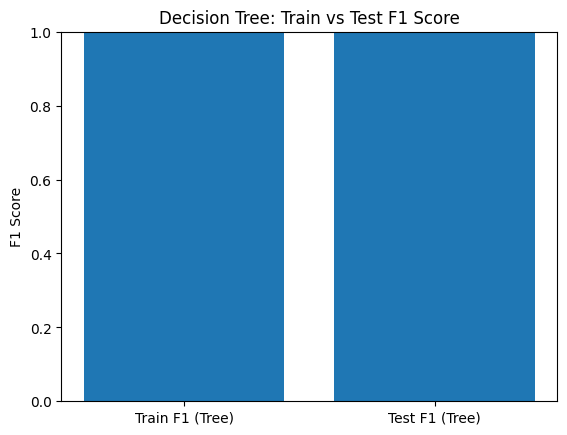

NameError: name 'train_preds_ann' is not defined

In [20]:
# Decision Tree F1 Scores
train_f1_tree = f1_score(y_train, best_tree_manual.predict(X_train))
test_f1_tree = f1_score(y_test, best_tree_manual.predict(X_test))

plt.figure()
plt.bar(["Train F1 (Tree)", "Test F1 (Tree)"], [train_f1_tree, test_f1_tree])
plt.title("Decision Tree: Train vs Test F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

# ANN F1 Scores
train_f1_ann = f1_score(y_train, train_preds_ann)
test_f1_ann = f1_score(y_test, preds)

plt.figure()
plt.bar(["Train F1 (ANN)", "Test F1 (ANN)"], [train_f1_ann, test_f1_ann])
plt.title("ANN: Train vs Test F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

In [ ]:
Bias–Variance: Decision Trees have low bias, high variance; ANN balances bias-variance better.

Stability: ANN is more stable across runs than Decision Trees.

Tuning Effort: Optuna is more efficient than GridSearch for hyperparameter tuning.

Scalability: ANN scales better with large datasets.

Interpretability: Decision Trees are more interpretable than ANN.

Robustness to Noise: ANN handles label noise better than Decision Trees.